In [1]:
import numpy as np
import pylab as plt
from scipy.signal import csd
import torch
from torch import optim
from nflows import transforms, distributions, flows
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
plt.rcParams.update({'font.size': 30})

In [2]:
background = np.load('Datasets/background.npz')['data']
bbh = np.load('Datasets/bbh_for_challenge.npy')
sglf = np.load('Datasets/sglf_for_challenge.npy')
print(background.shape)

(100000, 2, 200)


In [85]:
N_total = background.shape[0]
background_cs = np.zeros((N_total, 101))
bbh_cs = np.zeros((bbh.shape[0], 101))
sglf_cs = np.zeros((sglf.shape[0], 101))
for i in range(N_total):
    f, Pxx = csd(background[i,0,:], background[i,1,:])
    background_cs[i] = np.abs(Pxx)

    f, Pxx = csd(bbh[i,0,:], bbh[i,1,:])
    bbh_cs[i] = np.abs(Pxx)

    f, Pxx = csd(sglf[i,0,:], sglf[i,1,:])
    sglf_cs[i] = np.abs(Pxx)

/Users/ASK126/miniconda3/envs/myenv/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:1999: UserWarning: nperseg = 256 is greater than input length  = 200, using nperseg = 200
  warnings.warn('nperseg = {0:d} is greater than input length '


In [86]:
x = background_cs
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_train, x_val = train_test_split(x_scaled, test_size=0.2, random_state=42)

from sklearn.decomposition import PCA
pca = PCA(n_components=70)  # Retain 100 dimensions
x_train_pca = pca.fit_transform(x_train)
x_val_pca = pca.transform(x_val)

explained_variance_ratio = pca.explained_variance_ratio_

# Total variance retained
total_variance_retained = np.sum(explained_variance_ratio)
print(f"Total Variance Retained: {total_variance_retained:.2%}")


Total Variance Retained: 95.08%


In [87]:
d = x_train_pca.shape[1]
num_layers = 3

base_dist = distributions.StandardNormal(shape=[d])
transforms_array = []

for _ in range(num_layers):
    transforms_array.append(transforms.ReversePermutation(features=d))
    transforms_array.append(transforms.MaskedAffineAutoregressiveTransform(features=d, hidden_features=16))

transform = transforms.CompositeTransform(transforms_array)

flow = flows.Flow(transform, base_dist)

lr = 1e-2
optimizer = optim.Adam(flow.parameters(), lr=lr, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30,800], gamma=0.1)


In [88]:
batch_size = 5000
n_epochs = 60
N_train = x_train_pca.shape[0]
n_batches = N_train // batch_size

epoch_losses = []
val_losses = []
for epoch in range(n_epochs):
    flow.train()
    batch_losses = []
    for i in range(n_batches):
        batch_inds = np.random.choice(N_train, size=batch_size, replace=False)
        x_batch = torch.tensor(x_train_pca[batch_inds], dtype=torch.float32)
        optimizer.zero_grad()
        loss = -flow.log_prob(inputs=x_batch).mean()
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    epoch_losses.append(np.mean(batch_losses))

    flow.eval()
    val_loss = -flow.log_prob(torch.tensor(x_val_pca, dtype=torch.float32)).mean().item()
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {epoch_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, LR: {scheduler.get_last_lr()[0]:.2e}")

    scheduler.step()

Epoch 1/60, Train Loss: 125.7034, Val Loss: 105.6600, LR: 1.00e-02
Epoch 2/60, Train Loss: 104.5491, Val Loss: 102.4902, LR: 1.00e-02
Epoch 3/60, Train Loss: 101.7813, Val Loss: 101.0885, LR: 1.00e-02
Epoch 4/60, Train Loss: 100.8207, Val Loss: 100.6129, LR: 1.00e-02
Epoch 5/60, Train Loss: 100.4619, Val Loss: 100.4312, LR: 1.00e-02
Epoch 6/60, Train Loss: 100.3502, Val Loss: 100.2966, LR: 1.00e-02
Epoch 7/60, Train Loss: 100.2128, Val Loss: 100.1886, LR: 1.00e-02
Epoch 8/60, Train Loss: 100.1393, Val Loss: 100.1005, LR: 1.00e-02
Epoch 9/60, Train Loss: 100.1411, Val Loss: 100.0264, LR: 1.00e-02
Epoch 10/60, Train Loss: 100.0263, Val Loss: 99.9561, LR: 1.00e-02
Epoch 11/60, Train Loss: 99.9736, Val Loss: 99.8999, LR: 1.00e-02
Epoch 12/60, Train Loss: 99.8596, Val Loss: 99.8491, LR: 1.00e-02
Epoch 13/60, Train Loss: 99.8275, Val Loss: 99.8094, LR: 1.00e-02
Epoch 14/60, Train Loss: 99.7237, Val Loss: 99.7558, LR: 1.00e-02
Epoch 15/60, Train Loss: 99.7306, Val Loss: 99.7181, LR: 1.00e-02


(0.0, 200.0)

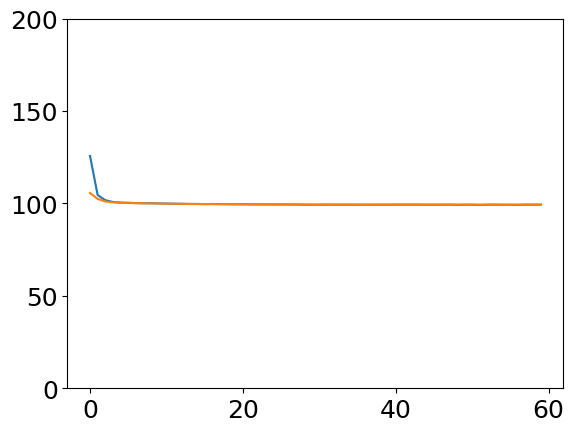

In [89]:
fig, ax = plt.subplots()

ax.plot(epoch_losses, label='Train Loss')
ax.plot(val_losses, label='Val Loss')
ax.set_ylim(0,200)


In [90]:
background_log_probs = flow.log_prob(torch.tensor(pca.transform(x_scaled), dtype=torch.float32)).detach().numpy()
background_latents = flow.transform_to_noise(torch.tensor(pca.transform(x_scaled), dtype=torch.float32)).detach().numpy()

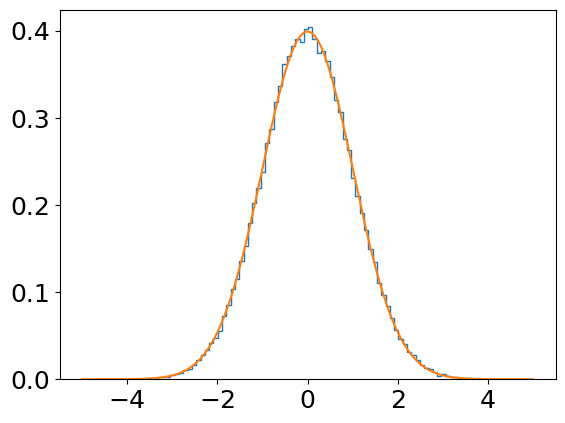

In [91]:
fig, ax = plt.subplots()

ax.hist(background_latents[:,3], bins=100, histtype='step', density=True);
x_plot = np.linspace(-5, 5, 1000)
ax.plot(x_plot, np.exp(-0.5*x_plot**2)/np.sqrt(2*np.pi), label='Standard Normal')

In [92]:
sglf_log_probs = flow.log_prob(torch.tensor(pca.transform(scaler.transform(sglf_cs)), dtype=torch.float32)).detach().numpy()
bbh_log_probs = flow.log_prob(torch.tensor(pca.transform(scaler.transform(bbh_cs)), dtype=torch.float32)).detach().numpy()

Text(0, 0.5, 'Density')

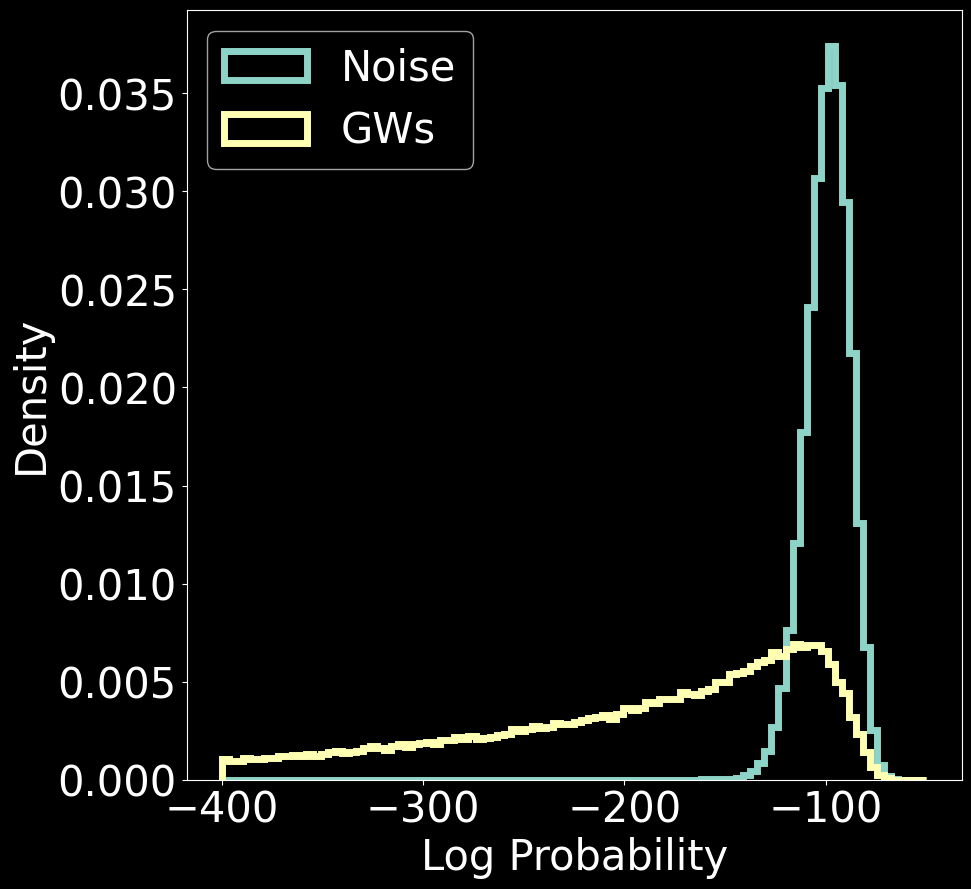

In [176]:
fig, ax = plt.subplots(figsize=(10,10))

ax.hist(background_log_probs, bins=100, range=(-400,-50), histtype='step', density=True, label='Noise', lw=5);
ax.hist(sglf_log_probs, bins=100, range=(-400,-50), histtype='step', density=True, label='GWs', lw=5);
#ax.hist(bbh_log_probs, bins=100, range=(-300,-50), histtype='step', density=True, label='BBH');
ax.legend()
ax.set_xlabel('Log Probability')
ax.set_ylabel('Density')

In [95]:
plt.style.use('dark_background')

(-2.0, 2.0)

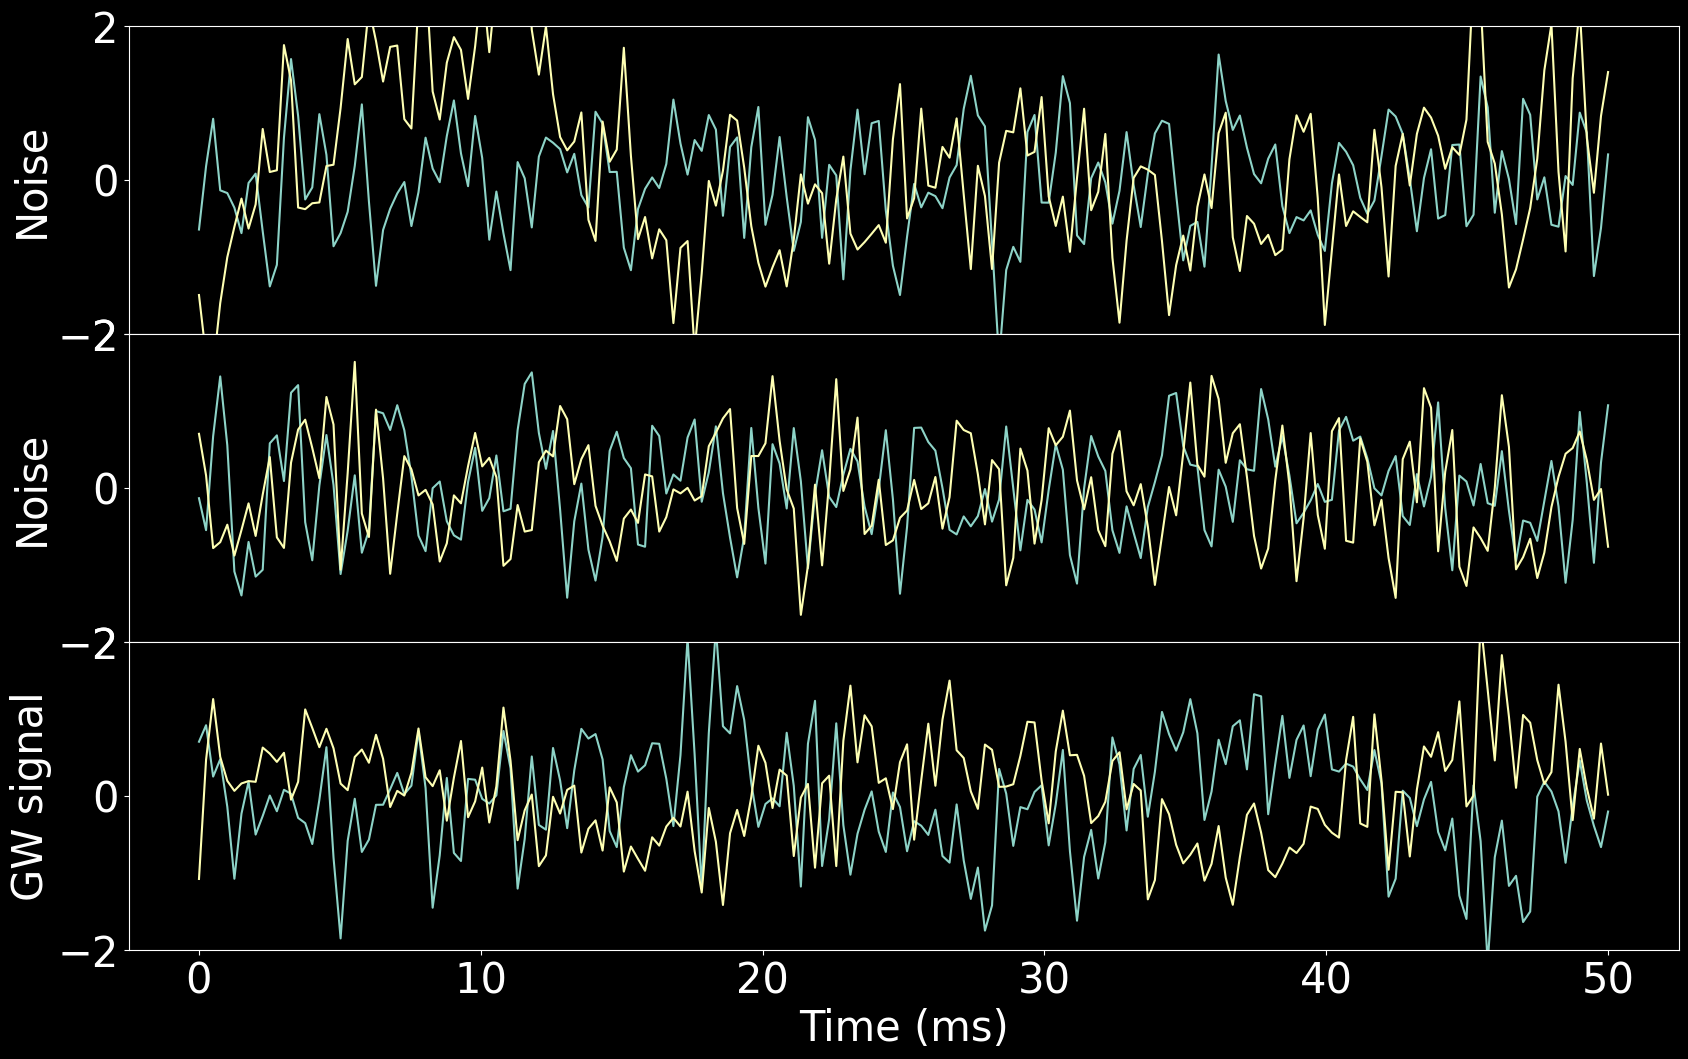

In [179]:
time_x = np.linspace(0, 50, 200)

sorter = np.argsort(background_log_probs)
i_background = sorter[np.searchsorted(background_log_probs, -150, sorter=sorter)]

sorter = np.argsort(bbh_log_probs)
i_bbh = sorter[np.searchsorted(bbh_log_probs, -450, sorter=sorter)]

fig, ax = plt.subplots(nrows=3, figsize=(20,12), sharex=True)
fig.subplots_adjust(hspace=0)

ax[0].plot(time_x, background[i_background,0,:], label='Detector 1')
ax[0].plot(time_x, background[i_background,1,:], label='Detector 2')

sorter = np.argsort(background_log_probs)
i_background2 = sorter[np.searchsorted(background_log_probs, -75, sorter=sorter)]
ax[1].plot(time_x, background[i_background2,0,:], label='Detector 1')
ax[1].plot(time_x, background[i_background2,1,:], label='Detector 2')

ax[2].plot(time_x, bbh[i_bbh,0,:])
ax[2].plot(time_x, bbh[i_bbh,1,:])
#ax[0].legend(loc='upper left')

ax[2].set_xlabel('Time (ms)')
ax[0].set_ylabel('Noise')
ax[1].set_ylabel('Noise')
ax[2].set_ylabel('GW signal')

ax[0].set_ylim(-2, 2)
ax[1].set_ylim(-2, 2)
ax[2].set_ylim(-2, 2)


In [182]:
1-bbh_probs[i_bbh], 1-background_probs[i_background], 1-background_probs[i_background2]

(0.006894255135668104, 0.009709969789784334, 0.9909385881451512)

In [108]:
list(plt.rcParams['axes.prop_cycle'])

[{'color': '#8dd3c7'},
 {'color': '#feffb3'},
 {'color': '#bfbbd9'},
 {'color': '#fa8174'},
 {'color': '#81b1d2'},
 {'color': '#fdb462'},
 {'color': '#b3de69'},
 {'color': '#bc82bd'},
 {'color': '#ccebc4'},
 {'color': '#ffed6f'}]

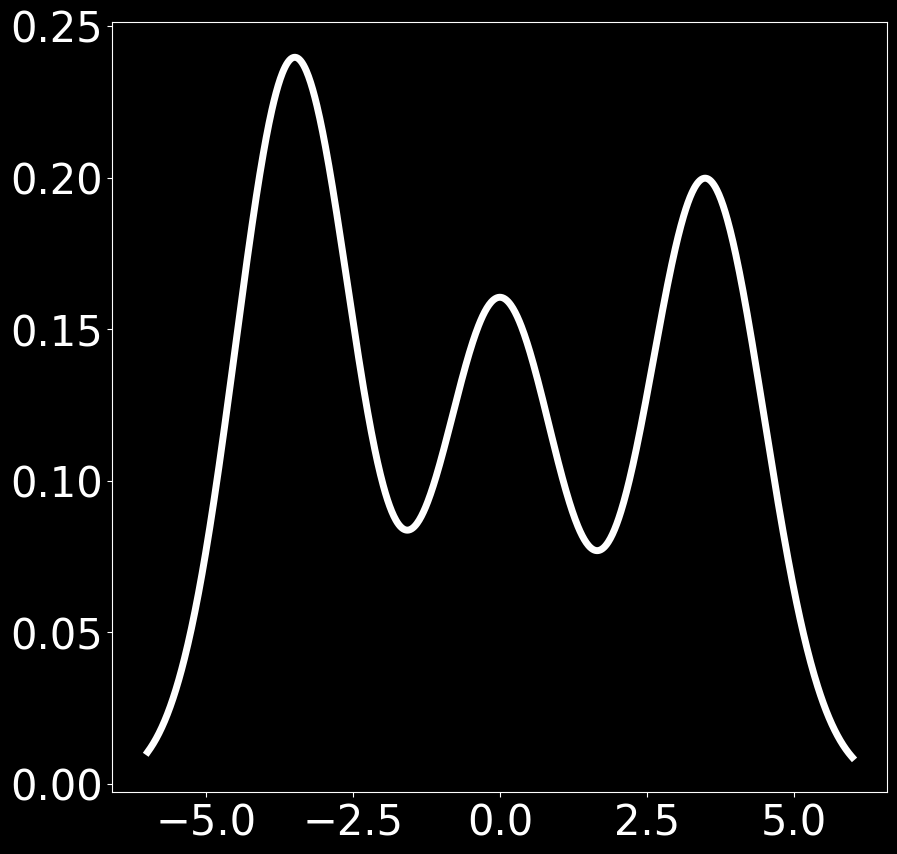

In [149]:
fig, ax = plt.subplots(figsize=(10,10))

x_gauss = np.linspace(-6, 6, 1000)
y_gauss = 0.5*np.exp(-0.5*(x_gauss-3.5)**2)/np.sqrt(2*np.pi) + 0.6*np.exp(-0.5*(x_gauss+3.5)**2)/np.sqrt(2*np.pi) + 0.4*np.exp(-0.5*(x_gauss)**2)/np.sqrt(2*np.pi) 
ax.plot(x_gauss, y_gauss, label='Standard Normal', lw=5, c='w')
#ax.grid()

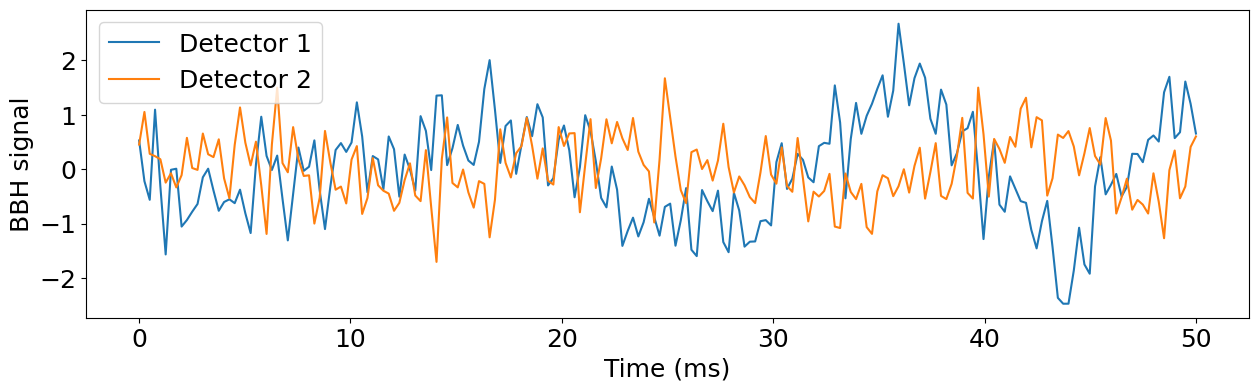

In [65]:
fig, ax = plt.subplots(figsize=(15,4))

ax.plot(time_x, bbh[i_bbh,0,:], label='Detector 1')
ax.plot(time_x, bbh[i_bbh,1,:], label='Detector 2')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('BBH signal')
ax.legend()



Text(0, 0.5, 'Signal')

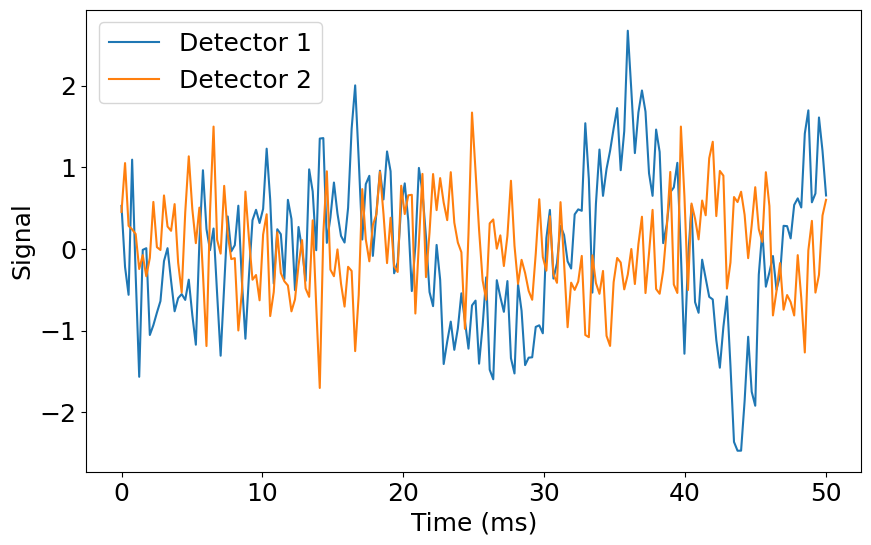

In [66]:


fig, ax = plt.subplots(figsize=(10,6))
ax.plot(time_x, bbh[i_bbh,0,:], label='Detector 1')
ax.plot(time_x, bbh[i_bbh,1,:], label='Detector 2')
ax.legend()
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Signal')

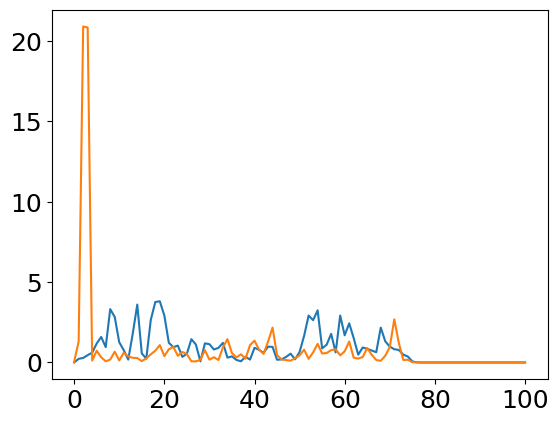

In [67]:
fig, ax = plt.subplots()

ax.plot(background_cs[i_background], label='Background')
ax.plot(bbh_cs[i_bbh], label='BBH')


In [68]:
probability_array = np.linspace(-150, -50, 100)

fpr = []
tpr_bbh = []
tpr_sglf = []

for p in probability_array:
    fp = np.sum(background_log_probs < p)
    tn = np.sum(background_log_probs >= p)
    fpr.append(fp / (fp + tn))

    tp_bbh = np.sum(bbh_log_probs < p)
    tp_sglf = np.sum(sglf_log_probs < p)

    fn_bbh = np.sum(bbh_log_probs >= p)
    fn_sglf = np.sum(sglf_log_probs >= p)

    tpr_bbh.append(tp_bbh / (tp_bbh + fn_bbh))
    tpr_sglf.append(tp_sglf / (tp_sglf + fn_sglf))


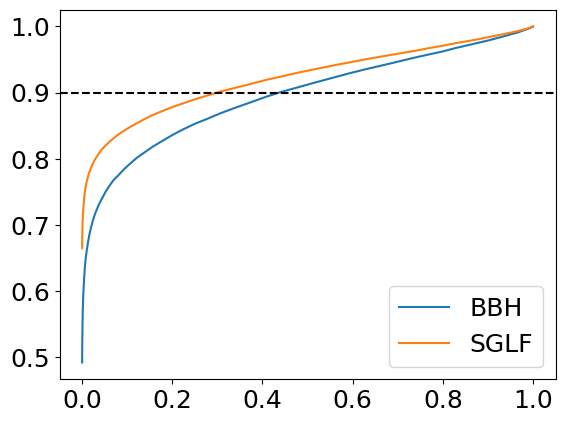

In [69]:
fig, ax = plt.subplots()

ax.plot(fpr, tpr_bbh, label='BBH')
ax.plot(fpr, tpr_sglf, label='SGLF')
ax.legend()
ax.axhline(0.9, color='black', linestyle='--')

In [70]:
#torch.save(flow.state_dict(), 'flow_model.pth')

In [71]:
# import pickle 

# with open('pca_model.pkl', 'wb') as f:
#     pickle.dump(pca, f)

# with open('scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

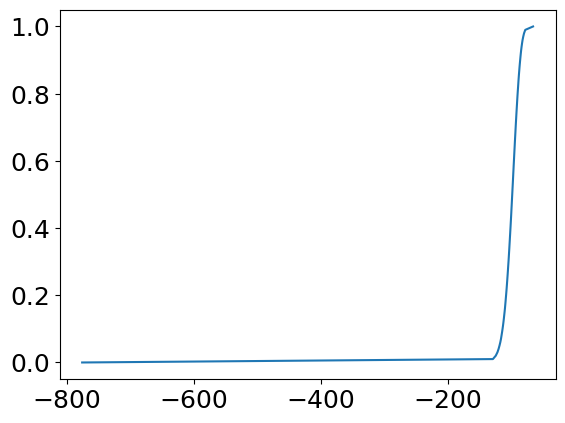

In [72]:
quantiles = np.linspace(0, 1, 100)
quantile_values = np.quantile(background_log_probs, quantiles)

fig, ax = plt.subplots()
ax.plot(quantile_values, quantiles)

In [73]:
bbh_quantiles = np.zeros(N_total)
sglf_quantiles = np.zeros(N_total)
background_quantiles = np.zeros(N_total)
for i in range(N_total):
    bbh_single_log_prob = bbh_log_probs[i]
    bbh_quantiles[i] = np.interp(bbh_single_log_prob, quantile_values, quantiles)

    sglf_single_log_prob = sglf_log_probs[i]
    sglf_quantiles[i] = np.interp(sglf_single_log_prob, quantile_values, quantiles)

    background_single_log_prob = background_log_probs[i]
    background_quantiles[i] = np.interp(background_single_log_prob, quantile_values, quantiles)



In [74]:
#np.save('quantiles.npy', quantiles)
#np.save('quantile_values.npy', quantile_values)

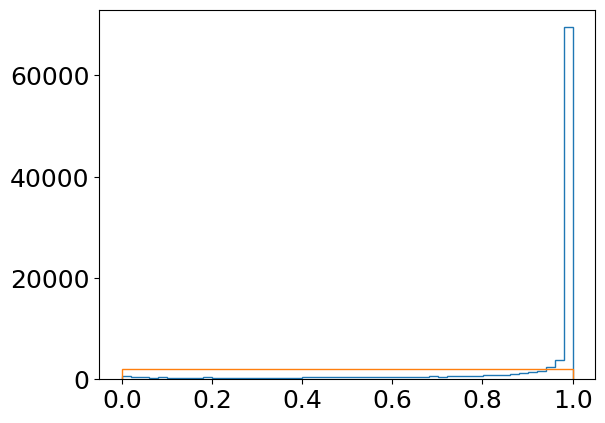

In [75]:
fig, ax = plt.subplots()

ax.hist(1-bbh_quantiles, bins=50, histtype='step', label='BBH');
#ax.hist(1-sglf_quantiles, bins=50, histtype='step', label='SGLF');
ax.hist(1-background_quantiles, bins=50, histtype='step', label='Background');

In [76]:
bbh_probs = 1-bbh_quantiles
sglf_probs = 1-sglf_quantiles
background_probs = 1-background_quantiles

In [77]:
p_array = np.linspace(0, 1, 1000)

fpr = []
tpr_bbh = []
tpr_sglf = []

for p in p_array:
    fp = np.sum(background_probs > p)
    tn = np.sum(background_probs <= p)
    fpr.append(fp / (fp + tn))

    tp_bbh = np.sum(bbh_probs > p)
    tp_sglf = np.sum(sglf_probs > p)

    fn_bbh = np.sum(bbh_probs <= p)
    fn_sglf = np.sum(sglf_probs <= p)

    tpr_bbh.append(tp_bbh / (tp_bbh + fn_bbh))
    tpr_sglf.append(tp_sglf / (tp_sglf + fn_sglf))


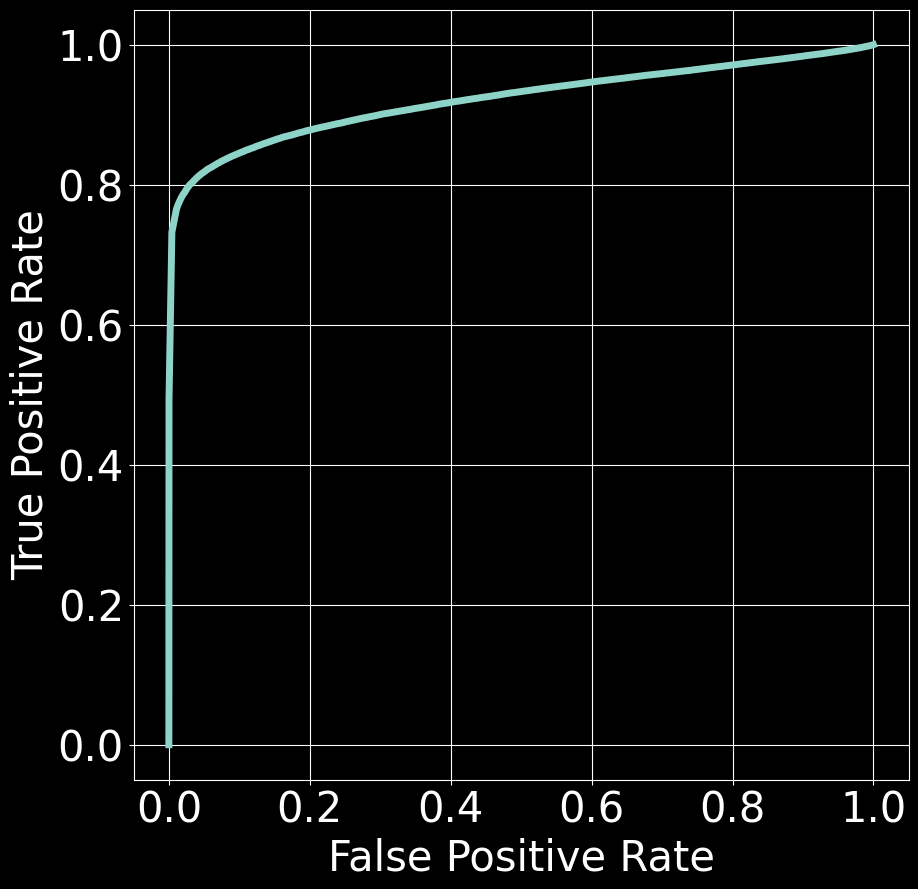

In [174]:
fig, ax = plt.subplots(figsize=(10,10))

#ax.plot(fpr, tpr_bbh, label='BBH')
ax.plot(fpr, tpr_sglf, label='SGLF', lw=5)
#ax.legend()
#ax.axhline(0.9, color='black', linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.grid()


In [82]:
np.trapz(tpr_bbh[::-1], fpr[::-1]), np.trapz(tpr_sglf[::-1], fpr[::-1])

(0.8945112635500001, 0.9216482304000001)

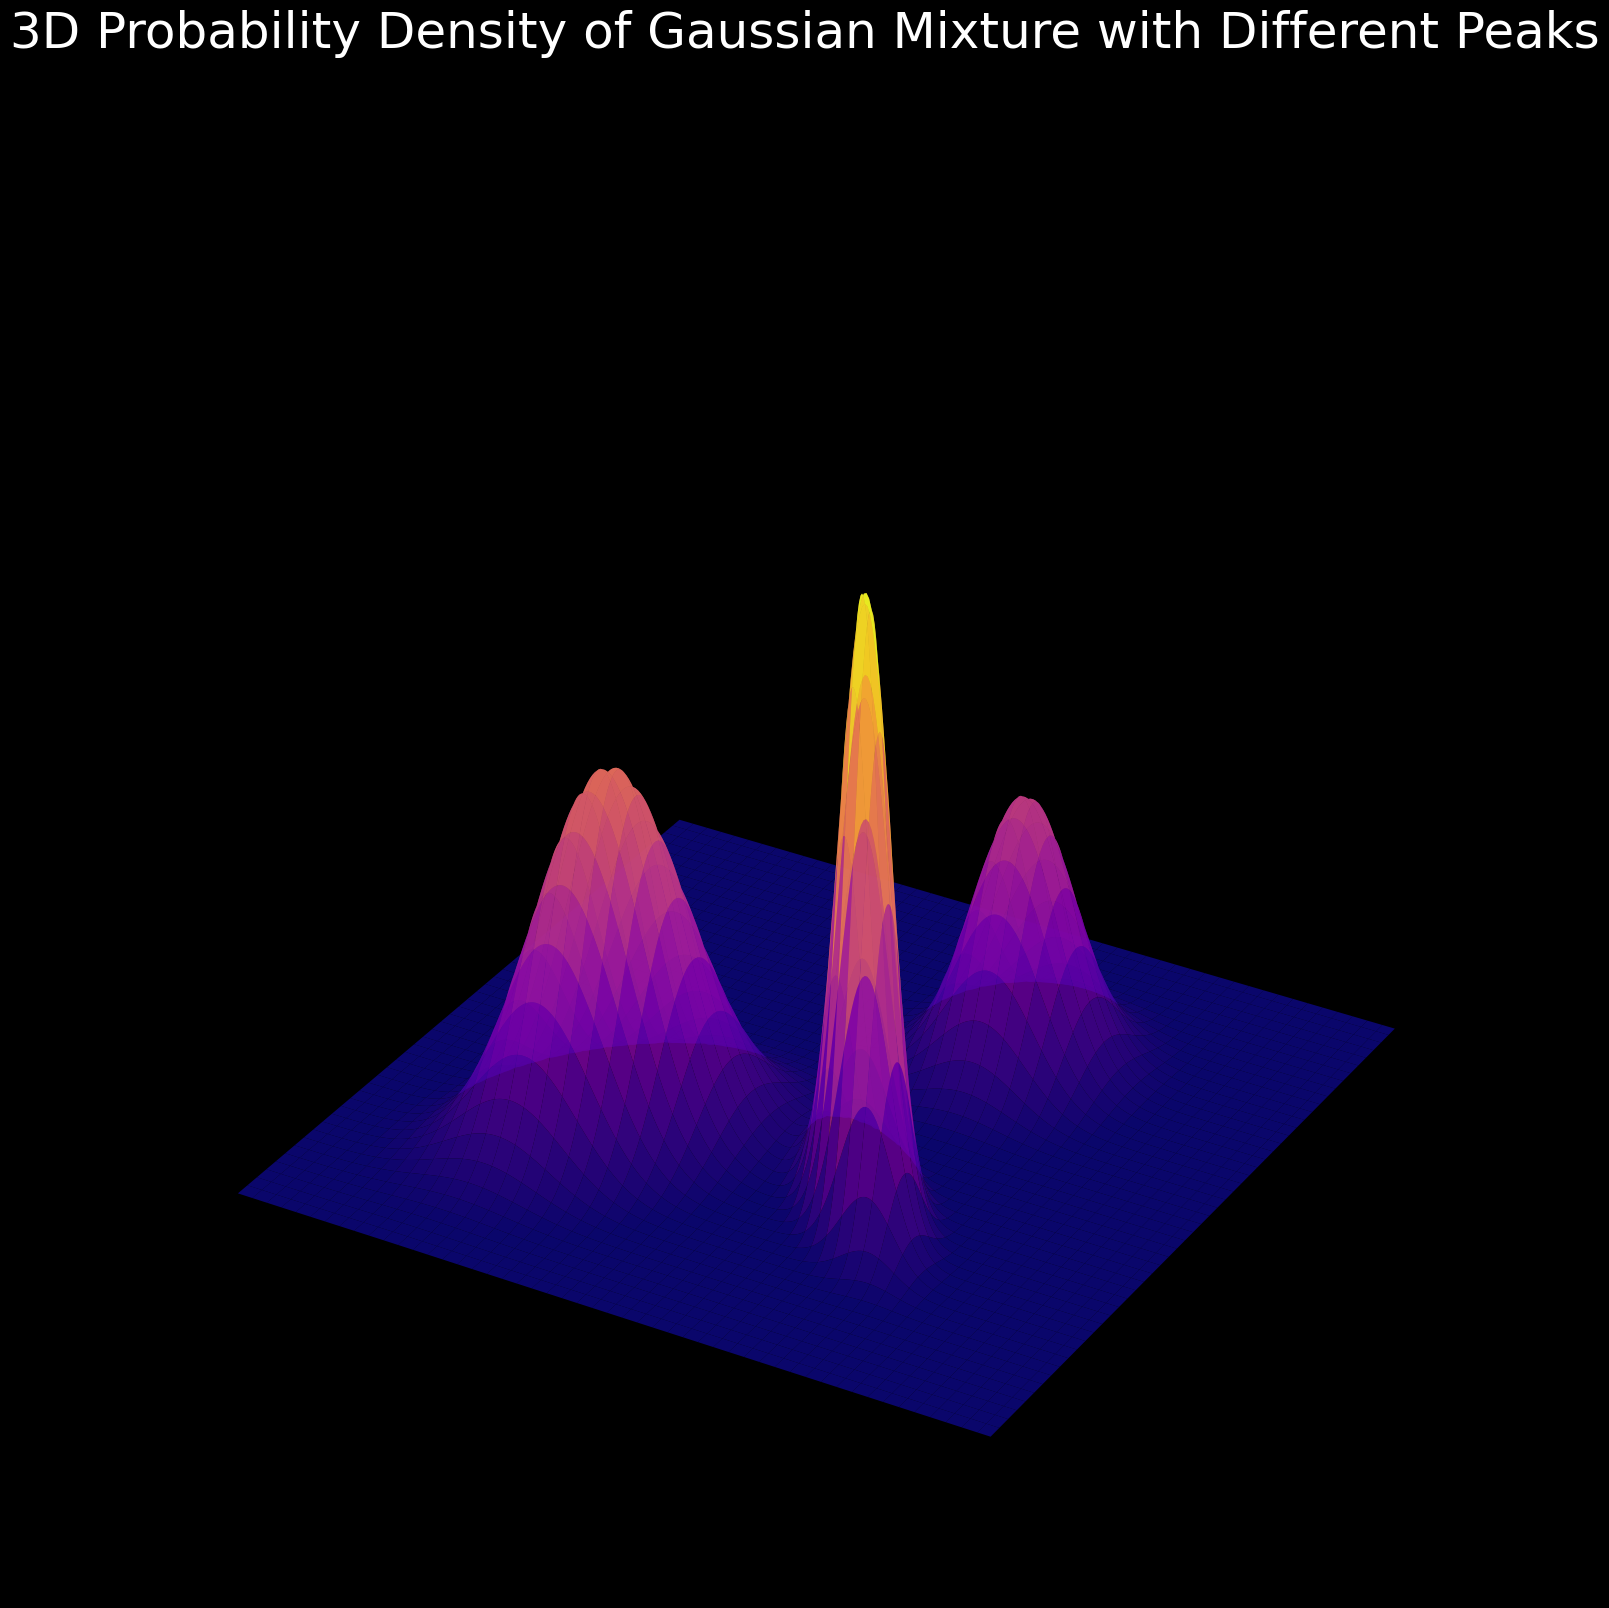

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal

# Set dark mode
plt.style.use('dark_background')

# Generate Gaussian distributions
def generate_gaussian_data(n, means, covs):
    data = []
    for mean, cov in zip(means, covs):
        blob = np.random.multivariate_normal(mean, cov, n)
        data.append(blob)
    return np.vstack(data)

# Define Gaussian centers, covariance matrices, and different peak heights
means = [[2, 2], [-2, -2], [2, -2]]
covs = [np.array([[0.5, 0], [0, 0.5]]),
        np.array([[0.8, 0.3], [0.3, 0.8]]),
        np.array([[0.3, -0.2], [-0.2, 0.3]])]
weights = [1, 2, 1]  # Different peak heights

# Generate data
num_points = 1000
data = generate_gaussian_data(num_points, means, covs)

# Compute probability density for visualization
xmin, xmax = np.min(data[:, 0]) - 1, np.max(data[:, 0]) + 1
ymin, ymax = np.min(data[:, 1]) - 1, np.max(data[:, 1]) + 1
x, y = np.meshgrid(np.linspace(xmin, xmax, 300), np.linspace(ymin, ymax, 300))
pos = np.dstack((x, y))

z = sum(weight * multivariate_normal(mean, cov).pdf(pos) for weight, mean, cov in zip(weights, means, covs))

# Plotting
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, cmap='plasma', edgecolor='none', alpha=0.8)

# Formatting
# ax.set_xlabel('X-axis', color='white')
# ax.set_ylabel('Y-axis', color='white')
# ax.set_zlabel('Probability Density', color='white')
ax.set_axis_off()
ax.set_title('3D Probability Density of Gaussian Mixture with Different Peaks', color='white')
ax.grid(False)

plt.show()


